# 하나의 ODE를 Solver / PINN / Neural ODE / RL로 보기

공통 동역학은 상태공간 $X=\mathbb{R}^2$ 위의 감쇠 조화진동자입니다.

$$x=(q,v),\qquad \frac{dq}{dt}=v,\qquad \frac{dv}{dt}=-kq-cv.$$

Solver는 기준해를 계산하고, PINN은 시간에서 상태로 가는 함수 $x_\theta:[0,T]\to X$를 학습하며, Neural ODE는 벡터장 $f_\theta:X\to X$를 학습합니다. RL에서는 같은 동역학에 제어 $u\in\mathbb{R}$를 추가하고 정책 $\pi_\theta:X\to\mathcal{P}(U)$를 학습합니다.

In [1]:
!pip -q install torchdiffeq
!git clone https://github.com/HisameOgasahara/RL_tmp.git

import sys
sys.path.append('/content/RL_tmp/src')

import torch

from rl_tmp.system import OscillatorConfig
from rl_tmp.solver import solve_reference, make_reference_dataset
from rl_tmp.pinn import train_pinn, predict_pinn
from rl_tmp.neural_ode import train_neural_ode, predict_neural_ode
from rl_tmp.rl import train_reinforce, rollout_policy
from rl_tmp.visualize import (
    plot_vector_field,
    plot_loss,
    plot_trajectory_comparison,
    plot_pinn_phase_field,
    plot_neural_ode_field_trajectory,
    plot_rl_closed_loop_field,
    plot_rl_rollout,
)


Cloning into 'RL_tmp'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 57 (delta 20), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 13.81 KiB | 2.30 MiB/s, done.
Resolving deltas: 100% (20/20), done.


## 공통 설정

**주어진 것:** $k>0$, $c\ge 0$, 초기상태 $x_0\in\mathbb{R}^2$, 시간구간 $[0,T]$.

**목적:** 모든 방법에서 같은 실제 벡터장과 같은 평가 시간격자를 사용합니다.

In [2]:
spring = 1.0 # @param {type:"number"}
damping = 0.3 # @param {type:"number"}
t_final = 6.0 # @param {type:"number"}
eval_points = 121 # @param {type:"integer"}
q0 = 1.5 # @param {type:"number"}
v0 = 0.0 # @param {type:"number"}
seed = 0 # @param {type:"integer"}

device = 'cpu'
config = OscillatorConfig(spring=spring, damping=damping)
times = torch.linspace(0.0, t_final, eval_points)
initial_state = torch.tensor([q0, v0], dtype=torch.float32)
reference = solve_reference(initial_state, times, config)


## 1. ODE Solver

**목표:** 알려진 벡터장 $f:\mathbb{R}\times X\to X$에서 기준 궤적을 계산합니다.

**주어진 것:**
$$\frac{dx}{dt}=f(t,x),\qquad x(0)=x_0.$$

**구하고자 하는 것:** 함수 $x:[0,T]\to X$의 수치근사.

**수학적 인터페이스:**
$$\operatorname{Solve}(f,x_0,\{t_i\}_{i=0}^{N})\mapsto \{x(t_i)\}_{i=0}^{N}.$$

여기서는 RK4를 기준 solver로 사용합니다. 학습은 없습니다.

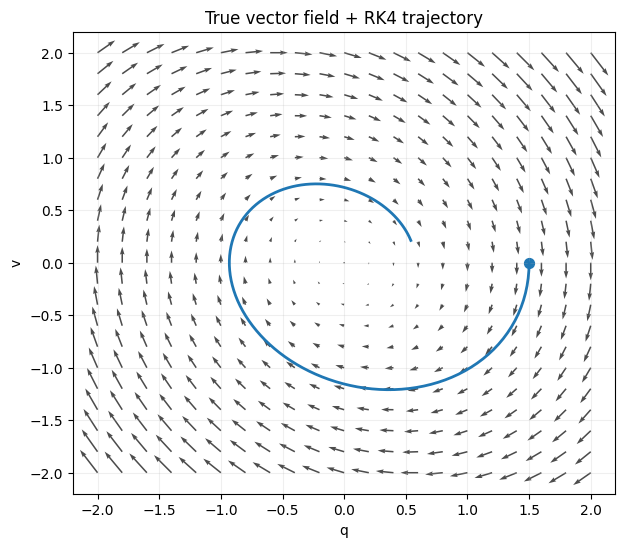

In [3]:
plot_vector_field(
    config=config,
    trajectory=reference,
    title='True vector field + RK4 trajectory',
)


## 2. PINN

**목표:** 미분방정식의 해 자체를 신경망으로 근사합니다.

**주어진 것:** 실제 벡터장 $f$와 초기조건 $x_0$.

**구하고자 하는 것:** 신경망 $x_\theta:[0,T]\to X$.

**수학적 인터페이스:**
$$x_\theta:t\mapsto (q_\theta(t),v_\theta(t)),$$
$$\mathcal{L}_{\mathrm{PINN}}(\theta)=\mathbb{E}_{t}\!\left[\left\|\frac{d x_\theta(t)}{dt}-f(t,x_\theta(t))\right\|_2^2\right]+\lambda\|x_\theta(0)-x_0\|_2^2.$$

Solver trajectory를 학습 target으로 주지 않고, ODE residual과 초기조건으로 학습합니다.

In [4]:
pinn_steps = 1500 # @param {type:"integer"}
pinn_lr = 0.001 # @param {type:"number"}
pinn_hidden = 64 # @param {type:"integer"}
pinn_layers = 2 # @param {type:"integer"}
collocation_points = 128 # @param {type:"integer"}
initial_weight = 10.0 # @param {type:"number"}

pinn_result = train_pinn(
    initial_state=initial_state,
    config=config,
    t_final=t_final,
    steps=pinn_steps,
    collocation_points=collocation_points,
    hidden_dim=pinn_hidden,
    hidden_layers=pinn_layers,
    learning_rate=pinn_lr,
    initial_weight=initial_weight,
    seed=seed,
    device=device,
)

pinn_prediction = predict_pinn(pinn_result.model, times, device=device)


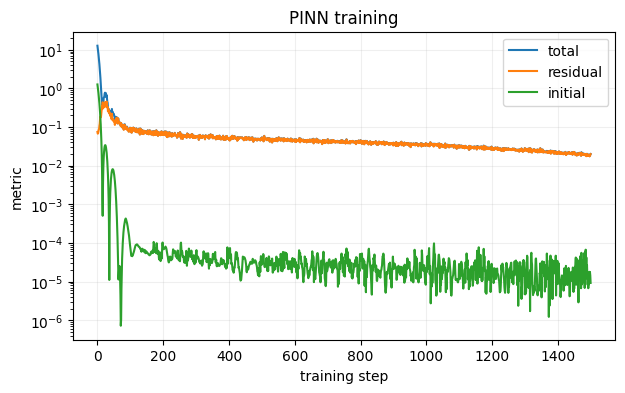

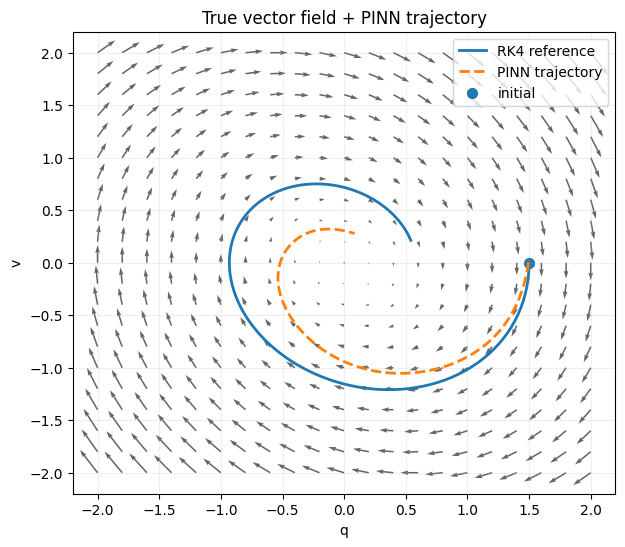

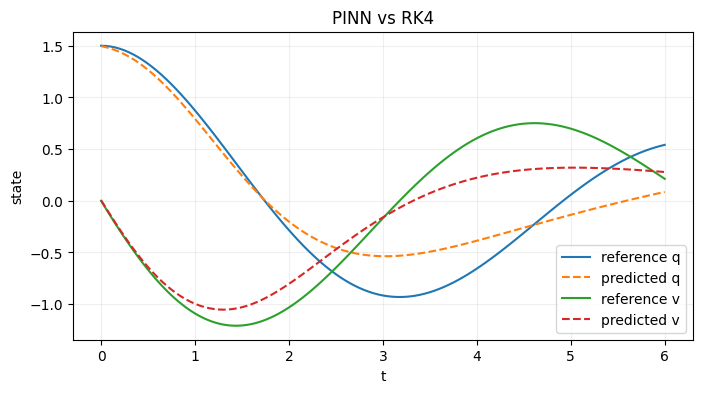

In [5]:
plot_loss(pinn_result.history, 'PINN training', log_scale=True)
plot_pinn_phase_field(
    config=config,
    reference=reference,
    pinn_trajectory=pinn_prediction,
)
plot_trajectory_comparison(times, reference, pinn_prediction, 'PINN vs RK4')


## 3. Neural ODE

**목표:** 관측된 여러 trajectory로부터 알려지지 않은 벡터장을 학습합니다.

**주어진 것:** 초기상태 집합 $\{x_0^{(j)}\}$와 solver가 만든 관측 trajectory $\{x^{(j)}(t_i)\}$.

**구하고자 하는 것:** 벡터장 $f_\theta:X\to X$.

**수학적 인터페이스:**
$$\frac{d\hat{x}}{dt}=f_\theta(\hat{x}),\qquad \hat{x}(0)=x_0,$$
$$\mathcal{L}_{\mathrm{NODE}}(\theta)=\frac{1}{MN}\sum_{j,i}\|\hat{x}^{(j)}_\theta(t_i)-x^{(j)}(t_i)\|_2^2.$$

즉 PINN과 달리 실제 $f$를 loss에 넣지 않고 trajectory 데이터에서 $f_\theta$를 역으로 학습합니다.

In [6]:
node_steps = 500 # @param {type:"integer"}
node_lr = 0.001 # @param {type:"number"}
node_hidden = 64 # @param {type:"integer"}
node_layers = 2 # @param {type:"integer"}
train_trajectories = 8 # @param {type:"integer"}
train_points = 61 # @param {type:"integer"}
train_state_range = 1.5 # @param {type:"number"}

generator = torch.Generator().manual_seed(seed)
node_initial_states = (
    2.0 * torch.rand(train_trajectories, 2, generator=generator) - 1.0
) * train_state_range
node_times = torch.linspace(0.0, t_final, train_points)
node_targets = make_reference_dataset(node_initial_states, node_times, config)

node_result = train_neural_ode(
    initial_states=node_initial_states,
    times=node_times,
    target_trajectories=node_targets,
    steps=node_steps,
    hidden_dim=node_hidden,
    hidden_layers=node_layers,
    learning_rate=node_lr,
    seed=seed,
    device=device,
)

node_prediction = predict_neural_ode(
    node_result.model,
    initial_state,
    times,
    device=device,
)


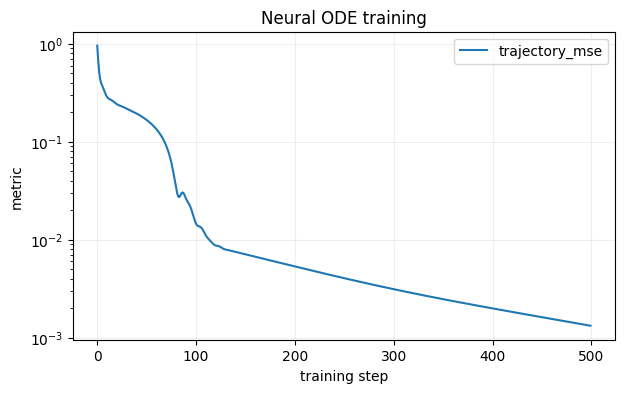

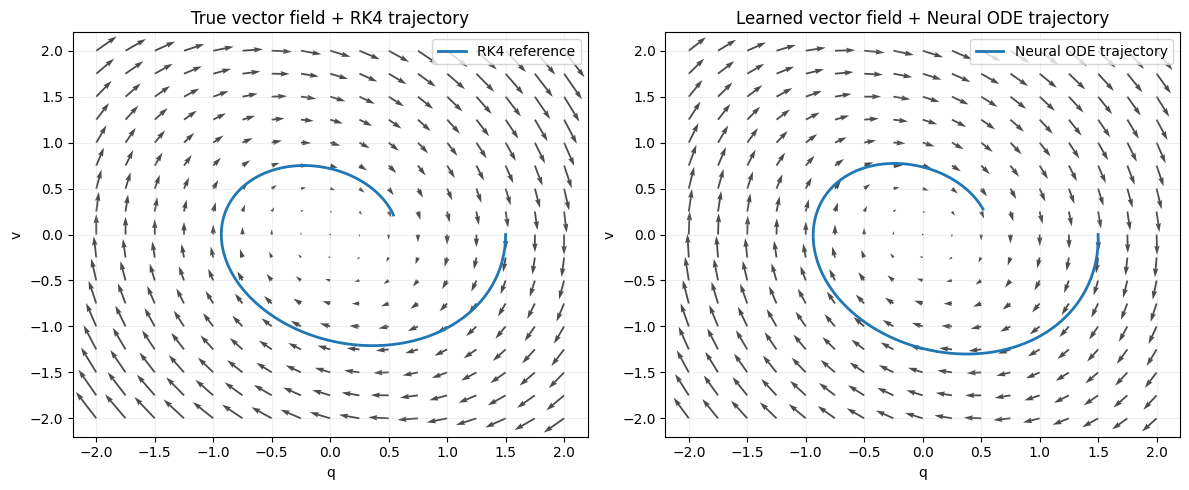

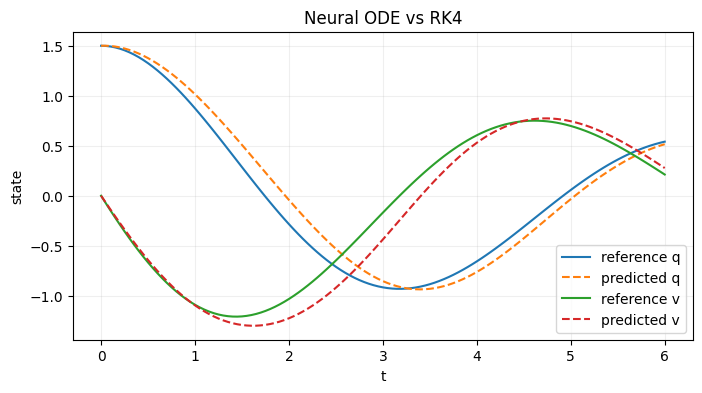

In [7]:
plot_loss(node_result.history, 'Neural ODE training', log_scale=True)
plot_neural_ode_field_trajectory(
    true_config=config,
    learned_model=node_result.model,
    reference=reference,
    learned_trajectory=node_prediction,
    device=device,
)
plot_trajectory_comparison(times, reference, node_prediction, 'Neural ODE vs RK4')


## 4. Reinforcement Learning

**목표:** 방정식을 근사하는 대신, 동역학 위에서 목표상태로 이동시키는 제어정책을 학습합니다.

**주어진 것:** 제어 가능한 시스템
$$\frac{dq}{dt}=v,\qquad \frac{dv}{dt}=-kq-cv+u,$$
초기상태 $x_0^{\mathrm{RL}}$, 목표상태 $x_{\mathrm{goal}}$, 그리고 보상함수.

**구하고자 하는 것:** 확률적 정책 $\pi_\theta:X\to\mathcal{P}(U)$.

**수학적 인터페이스:** 상태 $x_t\in X$, 행동 $u_t\in U=\mathbb{R}$에 대해
$$u_t\sim\pi_\theta(\cdot\mid x_t),$$
$$r_t=-\left(\|x_{t+1}-x_{\mathrm{goal}}\|_2^2+\alpha\|u_t\|_2^2\right),$$
$$\max_\theta J(\theta)=\mathbb{E}_{\pi_\theta}\left[\sum_{t=0}^{H-1}\gamma^t r_t\right].$$

여기서는 가장 단순한 policy-gradient 계열인 REINFORCE를 사용합니다.

In [8]:
rl_q0 = -1.0 # @param {type:"number"}
rl_v0 = 0.0 # @param {type:"number"}
goal_q = 1.0 # @param {type:"number"}
goal_v = 0.0 # @param {type:"number"}
rl_dt = 0.05 # @param {type:"number"}
rl_episodes = 800 # @param {type:"integer"}
rl_lr = 0.0003 # @param {type:"number"}
rl_hidden = 64 # @param {type:"integer"}
rl_layers = 2 # @param {type:"integer"}
gamma = 0.99 # @param {type:"number"}
action_cost = 0.01 # @param {type:"number"}
max_action = 3.0 # @param {type:"number"}

rl_initial_state = torch.tensor([rl_q0, rl_v0], dtype=torch.float32)
goal_state = torch.tensor([goal_q, goal_v], dtype=torch.float32)

rl_result = train_reinforce(
    initial_state=rl_initial_state,
    goal_state=goal_state,
    config=config,
    t_final=t_final,
    dt=rl_dt,
    episodes=rl_episodes,
    hidden_dim=rl_hidden,
    hidden_layers=rl_layers,
    learning_rate=rl_lr,
    gamma=gamma,
    action_cost=action_cost,
    max_action=max_action,
    seed=seed,
    device=device,
)

rl_times, controlled_states, rl_actions = rollout_policy(
    policy=rl_result.policy,
    initial_state=rl_initial_state,
    config=config,
    t_final=t_final,
    dt=rl_dt,
    max_action=max_action,
    device=device,
)

uncontrolled_states = solve_reference(rl_initial_state, rl_times, config)


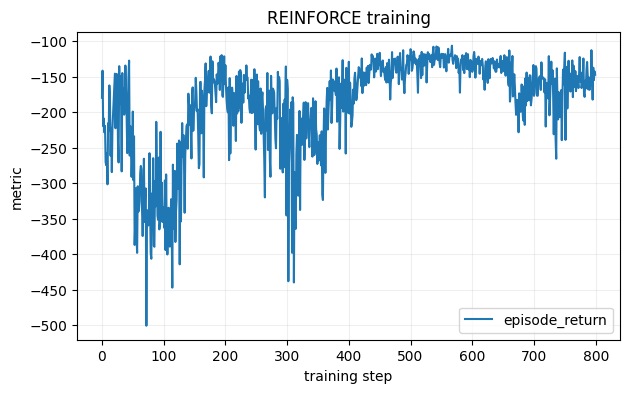

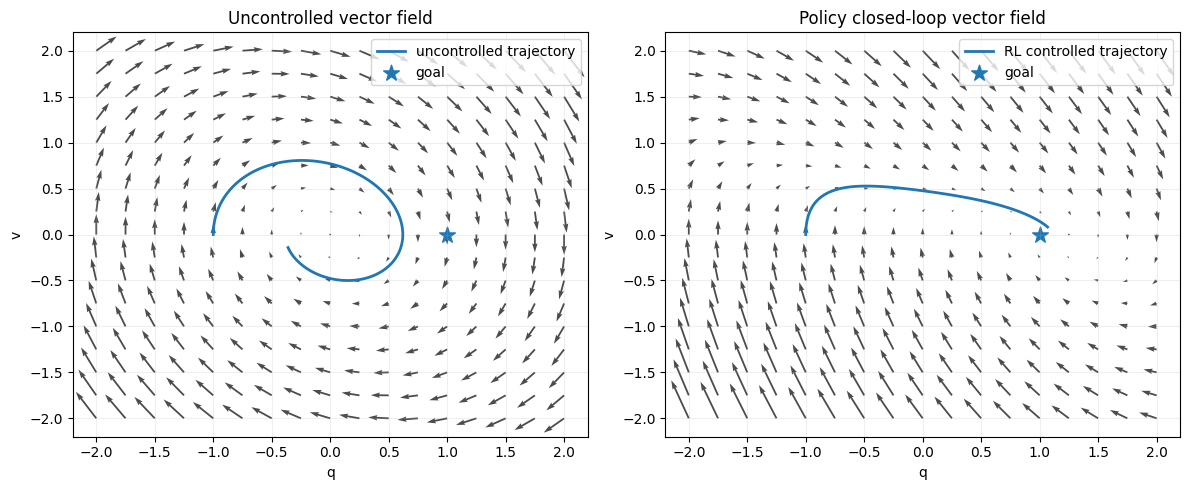

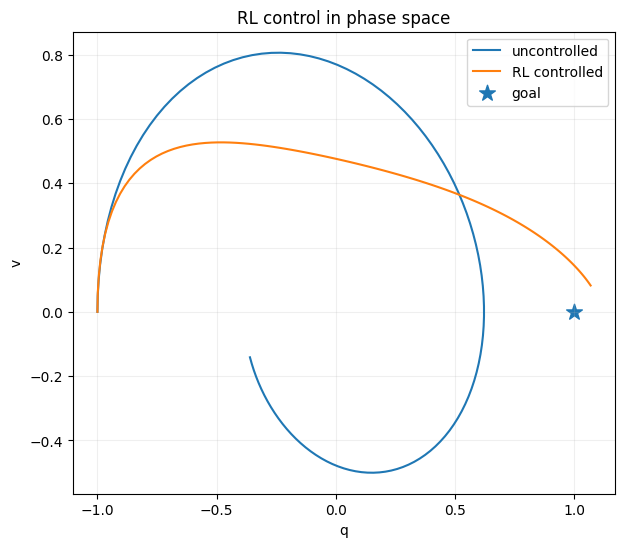

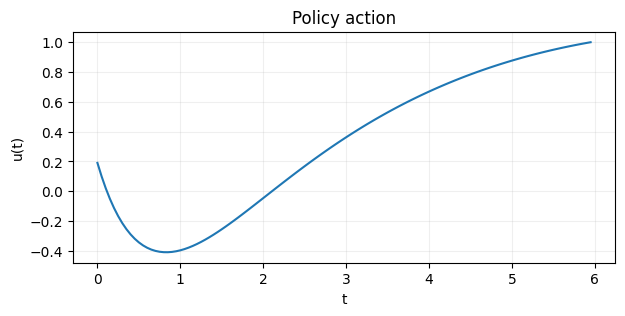

In [9]:
plot_loss(rl_result.history, 'REINFORCE training')
plot_rl_closed_loop_field(
    policy=rl_result.policy,
    config=config,
    uncontrolled=uncontrolled_states,
    controlled=controlled_states,
    goal_state=goal_state,
    max_action=max_action,
    device=device,
)
plot_rl_rollout(
    uncontrolled=uncontrolled_states,
    controlled=controlled_states,
    goal_state=goal_state,
    actions=rl_actions,
    times=rl_times,
)


## 최종 비교

- Solver: 알려진 $f$로 $x(t)$를 계산.
- PINN: 알려진 $f$의 미분방정식 제약으로 $x_\theta(t)$를 학습.
- Neural ODE: trajectory 데이터로 $f_\theta(x)$를 학습.
- RL: 제어 가능한 $f(x,u)$ 위에서 정책 $\pi_\theta(u\mid x)$를 학습.

In [10]:
pinn_mse = torch.mean((pinn_prediction - reference) ** 2).item()
node_mse = torch.mean((node_prediction - reference) ** 2).item()
rl_final_distance = torch.linalg.vector_norm(controlled_states[-1] - goal_state).item()

print(f'PINN trajectory MSE      : {pinn_mse:.6e}')
print(f'Neural ODE trajectory MSE: {node_mse:.6e}')
print(f'RL final goal distance   : {rl_final_distance:.6e}')


PINN trajectory MSE      : 5.969583e-02
Neural ODE trajectory MSE: 1.837317e-02
RL final goal distance   : 1.063453e-01
